In [1]:
from dotenv import load_dotenv
from agents import Agent, Runner, trace, function_tool, OpenAIChatCompletionsModel, input_guardrail, GuardrailFunctionOutput
from openai.types.responses import ResponseTextDeltaEvent
import asyncio
from agents import Agent, Runner, trace, function_tool
from typing import Dict, List, Optional
import json
import pandas as pd
from datetime import datetime
import os
import nest_asyncio
from IPython.display import Markdown, display

import nest_asyncio
import asyncio
import matplotlib.pyplot as plt
import asyncio
from IPython.display import display, Markdown
from collections import Counter

In [2]:
nest_asyncio.apply()

In [19]:
load_dotenv(override=True)

True

In [122]:
inventory_df = None


In [123]:
def load_data_new():
    """
    Load deduplicated inventory data into pandas DataFrame.
    Reads from data/carapi_unique_inventory.json
    (same folder as the .ipynb file)
    """
    global inventory_df

    try:
        file_path = os.path.join("data", "carapi_unique_inventory.json")

        with open(file_path, "r") as f:
            inventory_data = json.load(f)

        inventory_df = pd.DataFrame(inventory_data)
        return True

    except Exception as e:
        print(f"Error loading inventory: {e}")
        return False

# Main Code

In [161]:
inventory_df = None


def load_data_new():
    """
    Load deduplicated inventory data into pandas DataFrame.
    Reads from API/data/CAR_UNIQUE_DATA.json
    """
    global inventory_df

    try:
        file_path = os.path.join("API", "data", "CAR_UNIQUE_DATA.json")

        with open(file_path, "r") as f:
            inventory_data = json.load(f)

        inventory_df = pd.DataFrame(inventory_data)

        print(f"✅ Loaded {len(inventory_df)} unique vehicle models")
        return True

    except Exception as e:
        print(f"❌ Error loading inventory: {e}")
        inventory_df = None
        return False


# =========================
# BUDGET SEARCH TOOL
# =========================
@function_tool
def search_vehicles_by_budget(
    max_budget: int,
    min_budget: int = 0,
    limit: int = 10,
    max_per_make: int = 2
) -> List[Dict[str, Any]]:
    """
    Search vehicles within budget range.
    Ensures no more than `max_per_make` cars per make.
    Inventory is already deduplicated by model.
    """

    global inventory_df

    if inventory_df is None:
        if not load_data_new():
            return []

    def get_price(row):
        if isinstance(row.get("msrp"), (int, float)):
            return row["msrp"]
        if isinstance(row.get("price"), (int, float)):
            return row["price"]
        return None

    df = inventory_df.copy()
    df["computed_price"] = df.apply(get_price, axis=1)

    df = df[
        (df["computed_price"].notnull()) &
        (df["computed_price"] >= min_budget) &
        (df["computed_price"] <= max_budget)
    ]

    if df.empty:
        return []
    results = []
    make_count: Dict[str, int] = {}

    for _, row in df.iterrows():
        make = row.get("make")
        if not make:
            continue

        make_count.setdefault(make, 0)

        if make_count[make] < max_per_make:
            results.append(row.drop(labels=["computed_price"]).to_dict())
            make_count[make] += 1

        if len(results) >= limit:
            break

    return results


# =========================
# BUDGET RECOMMENDATION AGENT
# =========================
budget_recommendation_agent = Agent(
    name="Budget Recommendation Agent",
    instructions="""
You are a STRICTLY data-grounded budget-focused car recommendation agent.

MANDATORY RULES:
1. You MUST call `search_vehicles_by_budget`.
2. You are NOT allowed to answer from prior knowledge.
3. All recommendations MUST come from tool output.
4. Ensure no more than 2 cars per make.
5. If no cars are found, say so clearly.
6. Never output raw JSON.
7. Summarize results with make, model, year, and price.
""",
    tools=[search_vehicles_by_budget],
    model="gpt-4o-mini"
)

In [162]:
# =========================
# FAMILY VEHICLE TOOLS
# =========================

@function_tool
def search_vehicles_by_type(
    vehicle_type: str,
    limit: int = 20
):
    """
    Search vehicles by inferred type using description keywords.
    Supported types: suv, crossover, minivan, sedan
    """
    global inventory_df

    if inventory_df is None:
        load_data_new()

    keywords = {
        "suv": ["suv"],
        "crossover": ["crossover"],
        "minivan": ["minivan", "van"],
        "sedan": ["sedan"]
    }

    terms = keywords.get(vehicle_type.lower(), [])

    if not terms:
        return []

    mask = inventory_df["description"].fillna("").str.lower().apply(
        lambda x: any(term in x for term in terms)
    )

    df = inventory_df[mask]

    return df.head(limit).to_dict("records")


# =========================
# FAMILY VEHICLE AGENT
# =========================
family_vehicle_agent = Agent(
    name="Family Vehicle Agent",
    instructions="""
You are a family-focused vehicle recommendation agent.

MANDATORY RULES:
1. You MUST prioritize spacious and family-friendly vehicles.
2. You MUST call `search_vehicles_by_type` with SUV, crossover, or minivan.
3. If a budget is mentioned, you MUST also call `search_vehicles_by_budget`.
4. Use only tool outputs for recommendations.
5. Return up to 10 vehicles.
6. Summarize with make, model, year, and price.
7. Never output raw JSON.
""",
    tools=[
        search_vehicles_by_type,
        search_vehicles_by_budget
    ],
    model="gpt-4o-mini"
)


In [164]:
result = await Runner.run(
        family_vehicle_agent,
        "Find best family car $100,000"
)
print(result)

RunResult:
- Last agent: Agent(name="Family Vehicle Agent", ...)
- Final output (str):
    Here are some excellent family-friendly vehicles within your budget of $100,000:
    
    ### SUVs
    1. **Acura MDX**
       - **Year:** 2015
       - **Price:** $42,565
    
    2. **Acura RDX**
       - **Year:** 2015
       - **Price:** $35,095
    
    3. **Audi Q7**
       - **Year:** 2015
       - **Price:** $61,900
    
    4. **Audi Q5**
       - **Year:** 2015
       - **Price:** $51,900
    
    5. **Audi Q8**
       - **Year:** 2019
       - **Price:** $76,550
    
    ### Minivans
    6. **Honda Odyssey**
       - **Year:** 2015
       - **Price:** $32,275
    
    7. **Kia Sedona**
       - **Year:** 2015
       - **Price:** $32,300
    
    ### High-End SUVs
    8. **Cadillac Escalade**
       - **Year:** 2015
       - **Price:** $71,695
    
    9. **Cadillac Escalade ESV**
       - **Year:** 2015
       - **Price:** $74,695
    
    These options offer a good balance of comfort,

# Multipile Agents testing

## 1. Llama Agent

In [155]:
SYSTEM_PROMPT = """
You are a Budget Vehicle Recommendation Agent.

STRICT RULES:
- You must NOT generate vehicle data yourself.
- You must NOT use prior knowledge.
- You must NOT summarize before tool results are given.
- You must NOT include explanations, markdown, or extra text.

TO REQUEST DATA:
You MUST return ONLY a JSON object in this EXACT format:

{
  "tool": "search_vehicles_by_budget",
  "arguments": {
    "min_budget": 0,
    "max_budget": <integer>,
    "limit": 5,
    "max_per_make": 2
  }
}

AFTER TOOL RESULTS:
- Produce a numbered list.
- Each item MUST come from tool output.
- Include make, model, year, and price.
- Do NOT return JSON.
- Do NOT invent or modify values.
"""


# =========================
# TOOL SCHEMA (FOR LLaMA)
# =========================
TOOLS = {
    "search_vehicles_by_budget": {
        "description": "Find vehicles within a budget range with diversity constraints",
        "parameters": {
            "type": "object",
            "properties": {
                "min_budget": {"type": "integer"},
                "max_budget": {"type": "integer"},
                "limit": {"type": "integer"},
                "max_per_make": {"type": "integer"}
            },
            "required": ["max_budget"]
        }
    }
}


# =========================
# GROQ CALL
# =========================
def call_llama(messages):
    response = requests.post(
        "https://api.groq.com/openai/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {os.getenv('GROQ_API_KEY')}",
            "Content-Type": "application/json"
        },
        json={
            "model": "llama-3.1-8b-instant",
            "messages": messages,
            "temperature": 0
        }
    )

    data = response.json()
    print("🔴 RAW GROQ RESPONSE:", data)
    return data


# =========================
# TOOL CALL EXTRACTION
# =========================
def extract_tool_call(text):
    try:
        match = re.search(r"\{[\s\S]*\}", text)
        if not match:
            return None

        data = json.loads(match.group())
        if "tool" in data and "arguments" in data:
            return data

    except Exception:
        return None

    return None


# =========================
# PURE PYTHON TOOL IMPL
# =========================
def _search_vehicles_by_budget_impl(
    max_budget: int,
    min_budget: int = 0,
    limit: int = 5,
    max_per_make: int = 2
):
    global inventory_df

    if inventory_df is None:
        load_data_new()

    def get_price(row):
        if "msrp" in row and isinstance(row["msrp"], (int, float)):
            return row["msrp"]
        if "price" in row and isinstance(row["price"], (int, float)):
            return row["price"]
        return None

    df = inventory_df.copy()
    df["computed_price"] = df.apply(get_price, axis=1)

    df = df[
        (df["computed_price"].notnull()) &
        (df["computed_price"] >= min_budget) &
        (df["computed_price"] <= max_budget)
    ]

    results = []
    make_count = {}

    for _, row in df.iterrows():
        make = row.get("make")
        if not make:
            continue

        make_count.setdefault(make, 0)

        if make_count[make] < max_per_make:
            results.append(
                row.drop(columns=["computed_price"], errors="ignore").to_dict()
            )
            make_count[make] += 1

        if len(results) >= limit:
            break

    return results


# =========================
# MAIN LLaMA BUDGET AGENT
# =========================
def run_llama_budget_agent(user_query):
    tool_call_id = f"toolcall_{uuid.uuid4().hex}"

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_query}
    ]

    # 1️⃣ Ask LLaMA which tool to call
    response = call_llama(messages)

    if "choices" not in response:
        return f"GROQ ERROR: {response}"

    assistant_text = response["choices"][0]["message"]["content"]
    tool_call = extract_tool_call(assistant_text)

    if not tool_call:
        return "❌ ERROR: LLaMA did not produce a valid tool call."

    # 2️⃣ Execute REAL Python implementation (NOT FunctionTool)
    tool_result = _search_vehicles_by_budget_impl(
        **tool_call["arguments"]
    )

    # 3️⃣ Feed tool call + result back
    messages.append({
        "role": "assistant",
        "content": assistant_text,
        "tool_call_id": tool_call_id
    })

    messages.append({
        "role": "tool",
        "tool_call_id": tool_call_id,
        "content": json.dumps(tool_result)
    })

    # 4️⃣ Ask LLaMA to summarize grounded data
    final_response = call_llama(messages)

    if "choices" not in final_response:
        return f"GROQ ERROR AFTER TOOL: {final_response}"

    return final_response["choices"][0]["message"]["content"]


In [156]:
llama_output = run_llama_budget_agent("Find cars under $60,000")
print(llama_output)


🔴 RAW GROQ RESPONSE: {'id': 'chatcmpl-ecc89384-79ee-4425-8a80-b11ba142febf', 'object': 'chat.completion', 'created': 1766050405, 'model': 'llama-3.1-8b-instant', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': '{\n  "tool": "search_vehicles_by_budget",\n  "arguments": {\n    "min_budget": 0,\n    "max_budget": 60000,\n    "limit": 5,\n    "max_per_make": 2\n  }\n}'}, 'logprobs': None, 'finish_reason': 'stop'}], 'usage': {'queue_time': 0.050791407, 'prompt_tokens': 210, 'prompt_time': 0.012883392, 'completion_tokens': 54, 'completion_time': 0.04213041, 'total_tokens': 264, 'total_time': 0.055013802}, 'usage_breakdown': None, 'system_fingerprint': 'fp_1151d4f23c', 'x_groq': {'id': 'req_01kcrcx6kpf6n95jdzngw9ks8a', 'seed': 944323031}, 'service_tier': 'on_demand'}
🔴 RAW GROQ RESPONSE: {'id': 'chatcmpl-e786f752-34de-4c3e-be4f-91632f7e42ee', 'object': 'chat.completion', 'created': 1766050405, 'model': 'llama-3.1-8b-instant', 'choices': [{'index': 0, 'message': {'role': '

## 2. OPEN Ai Agent

In [144]:
# =========================
# GLOBAL STATE
# =========================
inventory_df = None


# =========================
# LOAD DEDUPLICATED DATA
# =========================
def load_data_new():
    """
    Load deduplicated inventory data into pandas DataFrame.
    Reads from API/data/CAR_UNIQUE_DATA.json
    """
    global inventory_df

    try:
        file_path = os.path.join("API", "data", "CAR_UNIQUE_DATA.json")

        with open(file_path, "r") as f:
            inventory_data = json.load(f)

        inventory_df = pd.DataFrame(inventory_data)

        print(f"✅ Loaded {len(inventory_df)} unique vehicle models")
        return True

    except Exception as e:
        print(f"❌ Error loading inventory: {e}")
        inventory_df = None
        return False


# =========================
# BUDGET SEARCH TOOL
# (WITH MAX 2 PER MAKE)
# =========================
@function_tool
def search_vehicles_by_budget(
    max_budget: int,
    min_budget: int = 0,
    limit: int = 10,
    max_per_make: int = 2
) -> List[Dict[str, Any]]:
    """
    Search vehicles within budget range.
    Ensures no more than `max_per_make` cars per make.
    Inventory is already deduplicated by model.
    """

    global inventory_df

    if inventory_df is None:
        if not load_data_new():
            return []

    def get_price(row):
        if isinstance(row.get("msrp"), (int, float)):
            return row["msrp"]
        if isinstance(row.get("price"), (int, float)):
            return row["price"]
        return None

    df = inventory_df.copy()
    df["computed_price"] = df.apply(get_price, axis=1)

    df = df[
        (df["computed_price"].notnull()) &
        (df["computed_price"] >= min_budget) &
        (df["computed_price"] <= max_budget)
    ]

    if df.empty:
        return []

    # 🔒 Enforce diversity: max N cars per make
    results = []
    make_count: Dict[str, int] = {}

    for _, row in df.iterrows():
        make = row.get("make")
        if not make:
            continue

        make_count.setdefault(make, 0)

        if make_count[make] < max_per_make:
            results.append(row.drop(labels=["computed_price"]).to_dict())
            make_count[make] += 1

        if len(results) >= limit:
            break

    return results


# =========================
# BUDGET RECOMMENDATION AGENT
# =========================
budget_recommendation_agent = Agent(
    name="Budget Recommendation Agent",
    instructions="""
You are a STRICTLY data-grounded budget-focused car recommendation agent.

MANDATORY RULES:
1. You MUST call `search_vehicles_by_budget`.
2. You are NOT allowed to answer from prior knowledge.
3. All recommendations MUST come from tool output.
4. Ensure no more than 2 cars per make.
5. If no cars are found, say so clearly.
6. Never output raw JSON.
7. Summarize results with make, model, year, and price.
""",
    tools=[search_vehicles_by_budget],
    model="gpt-4o-mini"
)

In [147]:
result = await Runner.run(
        budget_recommendation_agent,
        "Find cars below $60,000"
)
print(result)

RunResult:
- Last agent: Agent(name="Budget Recommendation Agent", ...)
- Final output (str):
    Here are some cars available under $60,000 from various makes:
    
    1. **Acura MDX**
       - Year: 2015
       - Price: $42,565
    
    2. **Acura RDX**
       - Year: 2015
       - Price: $35,095
    
    3. **Audi S4**
       - Year: 2015
       - Price: $54,300
    
    4. **Audi A6**
       - Year: 2015
       - Price: $44,800
    
    5. **BMW 530i**
       - Year: 2017
       - Price: $51,200
    
    6. **BMW 320i**
       - Year: 2015
       - Price: $32,950
    
    7. **Buick Regal**
       - Year: 2015
       - Price: $27,065
    
    8. **Buick LaCrosse**
       - Year: 2015
       - Price: $31,065
    
    9. **Cadillac CTS**
       - Year: 2015
       - Price: $45,345
    
    10. **Cadillac SRX**
        - Year: 2015
        - Price: $37,605
    
    Let me know if you need more information!
- 3 new item(s)
- 2 raw response(s)
- 0 input guardrail result(s)
- 0 output g

In [83]:
def extract_openai_text(run_result):
    if hasattr(run_result, "output_text"):
        return run_result.output_text
    if hasattr(run_result, "final_output"):
        return run_result.final_output
    return str(run_result)
openai_text = extract_openai_text(openai_output)


## Comparison

🔴 RAW GROQ RESPONSE: {'id': 'chatcmpl-46390df6-185d-4616-a5a2-0e4f10cc63ef', 'object': 'chat.completion', 'created': 1766050608, 'model': 'llama-3.1-8b-instant', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': '{\n  "tool": "search_vehicles_by_budget",\n  "arguments": {\n    "min_budget": 0,\n    "max_budget": 60000,\n    "limit": 5,\n    "max_per_make": 2\n  }\n}'}, 'logprobs': None, 'finish_reason': 'stop'}], 'usage': {'queue_time': 0.052298833, 'prompt_tokens': 217, 'prompt_time': 0.078362317, 'completion_tokens': 54, 'completion_time': 0.048251958, 'total_tokens': 271, 'total_time': 0.126614275}, 'usage_breakdown': None, 'system_fingerprint': 'fp_4387d3edbb', 'x_groq': {'id': 'req_01kcrd3d57fwcrqkq13tvbqj69', 'seed': 1317772841}, 'service_tier': 'on_demand'}
🔴 RAW GROQ RESPONSE: {'id': 'chatcmpl-6bbdd5c6-dcc3-4cef-9378-9fb585129170', 'object': 'chat.completion', 'created': 1766050608, 'model': 'llama-3.1-8b-instant', 'choices': [{'index': 0, 'message': {'role':

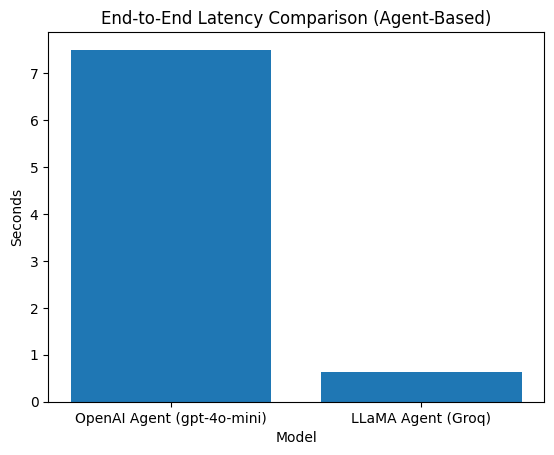

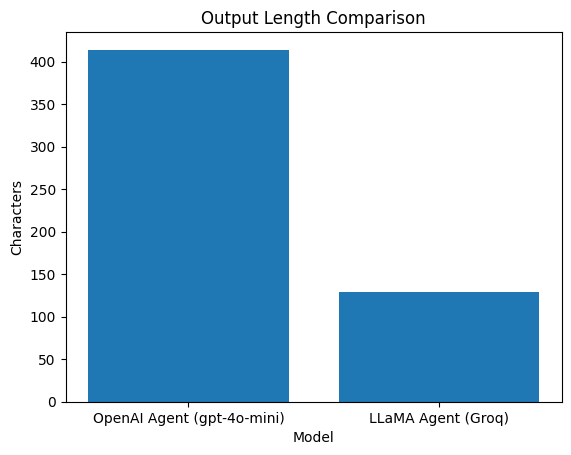

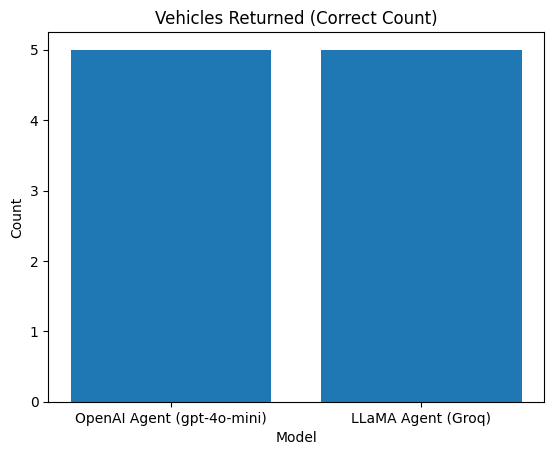

In [159]:
# ================================
# AGENT-BASED BENCHMARK (FIXED)
# OpenAI Agent vs LLaMA Agent
# ================================

import time
import pandas as pd
import matplotlib.pyplot as plt
import asyncio


# --------------------------------
# CONFIG
# --------------------------------
TEST_PROMPT = "Find cars under $60,000. Return exactly 5 cars."


# --------------------------------
# HELPERS
# --------------------------------
def count_vehicles_from_numbered_list(text: str) -> int:
    return sum(
        1 for line in text.splitlines()
        if line.strip().startswith(tuple(f"{i}." for i in range(1, 11)))
    )


# --------------------------------
# 1. OPENAI AGENT RUN (ASYNC FIX)
# --------------------------------
async def _run_openai_agent_async():
    start = time.time()

    result = await Runner.run(
        budget_recommendation_agent,
        TEST_PROMPT
    )

    latency = time.time() - start
    output = result.final_output

    return {
        "provider": "OpenAI Agent (gpt-4o-mini)",
        "latency_seconds": round(latency, 4),
        "output_length_chars": len(output),
        "num_vehicles_returned": count_vehicles_from_numbered_list(output),
        "output": output,
        "error": False
    }


def run_openai_agent():
    return asyncio.run(_run_openai_agent_async())


# --------------------------------
# 2. LLaMA AGENT RUN (GROQ)
# --------------------------------
def run_llama_agent():
    start = time.time()

    output = run_llama_budget_agent(TEST_PROMPT)

    latency = time.time() - start

    return {
        "provider": "LLaMA Agent (Groq)",
        "latency_seconds": round(latency, 4),
        "output_length_chars": len(output),
        "num_vehicles_returned": count_vehicles_from_numbered_list(output),
        "output": output,
        "error": False
    }


# --------------------------------
# 3. RUN BENCHMARK
# --------------------------------
results = [
    run_openai_agent(),
    run_llama_agent()
]

df = pd.DataFrame(results)

print(df[[
    "provider",
    "latency_seconds",
    "output_length_chars",
    "num_vehicles_returned"
]])


# --------------------------------
# 4. PLOTS
# --------------------------------

# Latency Plot
plt.figure()
plt.bar(df["provider"], df["latency_seconds"])
plt.title("End-to-End Latency Comparison (Agent-Based)")
plt.ylabel("Seconds")
plt.xlabel("Model")
plt.show()

# Output Length Plot
plt.figure()
plt.bar(df["provider"], df["output_length_chars"])
plt.title("Output Length Comparison")
plt.ylabel("Characters")
plt.xlabel("Model")
plt.show()

# Vehicles Returned Plot
plt.figure()
plt.bar(df["provider"], df["num_vehicles_returned"])
plt.title("Vehicles Returned (Correct Count)")
plt.ylabel("Count")
plt.xlabel("Model")
plt.show()


# Donot Touch Below

In [15]:
# Tools list for agents
vehicle_tools = [
    search_vehicles_by_budget,
    search_vehicles_by_type, 
    search_vehicles_by_features,
    get_fuel_efficient_vehicles,
    get_vehicles_by_safety_rating,
    get_vehicle_details,
    compare_vehicles,
    check_inventory_availability
]

In [16]:
# Budget-focused agent
budget_specialist = Agent(
    name="Budget Vehicle Specialist",
    instructions="""You are a budget-conscious vehicle specialist who helps customers find the best value vehicles within their price range. 
    
    You are expected to excel at:
    - Finding vehicles that maximize value for money
    - Identifying cost-effective options with good reliability
    - Explaining total cost of ownership
    - Highlighting vehicles with good resale value
    
    Always use the search tools to find current inventory and provide specific vehicle recommendations with pricing details.""",
    tools=vehicle_tools,
    model="gpt-4o-mini"
)

In [17]:
# Family-focused agent  
family_specialist = Agent(
    name="Family Vehicle Specialist", 
    instructions="""You are a family vehicle specialist who prioritizes safety, space, and practicality for families.
    
    You are an expet in:
    - Recommending vehicles based on family size and needs
    - Prioritizing safety ratings and family-friendly features
    - Considering cargo space, seating capacity, and convenience features
    - Understanding child safety requirements and accessibility
    
    Always use search tools to find vehicles that meet family requirements and emphasize safety ratings and practical features.""",
    tools=vehicle_tools,
    model="gpt-4o-mini"
)

In [18]:
# Performance/Luxury specialist
luxury_specialist = Agent(
    name="Luxury & Performance Specialist",
    instructions="""You are a luxury and performance vehicle specialist who focuses on premium features, advanced technology, and driving experience.
    
    You excel at:
    - Recommending vehicles with premium features and materials
    - Understanding performance specifications and driving dynamics  
    - Highlighting advanced technology and luxury amenities
    - Explaining the value proposition of premium vehicles
    
    Use search tools to find vehicles with luxury features and provide detailed explanations of premium benefits.""",
    tools=vehicle_tools,
    model="gpt-4o-mini"
)

In [19]:
eco_specialist = Agent(
    name="Eco-Friendly Vehicle Specialist",
    instructions="""You are an eco-friendly vehicle specialist focused on environmental impact, fuel efficiency, and sustainable transportation.
    
    You excel at:
    - Recommending electric, hybrid, and high-efficiency vehicles
    - Explaining environmental benefits and cost savings
    - Understanding charging infrastructure and range considerations
    - Calculating long-term fuel/energy cost savings
    
    Always prioritize vehicles with the best environmental credentials and use tools to find the most efficient options.""",
    tools=vehicle_tools,
    model="gpt-4o-mini"
)


In [20]:
# Convert specialist agents to tools
budget_tool = budget_specialist.as_tool(
    tool_name="budget_specialist",
    tool_description="Get budget-focused vehicle recommendations and value analysis"
)

family_tool = family_specialist.as_tool(
    tool_name="family_specialist", 
    tool_description="Get family-oriented vehicle recommendations focusing on safety and practicality"
)

luxury_tool = luxury_specialist.as_tool(
    tool_name="luxury_specialist",
    tool_description="Get luxury and performance vehicle recommendations"
)

eco_tool = eco_specialist.as_tool(
    tool_name="eco_specialist",
    tool_description="Get eco-friendly and fuel-efficient vehicle recommendations"
)

In [21]:
# Main orchestrating agent
vehicle_recommendation_agent = Agent(
    name="Vehicle Recommendation Manager",
    instructions="""You are the main vehicle recommendation manager who helps customers find their perfect vehicle.

Your process:
1. Understand the customer's needs, budget, and priorities.
2. Determine which specialist agent(s) would be most helpful.
3. Use appropriate specialist tools to get vehicle recommendations.
4. Use direct search tools when needed for specific queries.
5. Synthesize and compare recommendations from multiple sources.
6. Provide clear, actionable advice with specific vehicle suggestions.
7. Track which specialist tools were used during the recommendation process.
8. Identify which recommendations came from which tools.
9. Rank the tools based on their contribution to the final output:
   - Number of final recommendations they contributed
   - Relevance to the customer's stated needs
   - Helpfulness in shaping the final advice

Customer Priority Categories:
- Budget-conscious → Use budget_specialist
- Family needs → Use family_specialist  
- Luxury/performance → Use luxury_specialist
- Environmental/efficiency → Use eco_specialist

Always include in your response:
- 2–3 specific vehicle recommendations tailored to the customer
- Clear reasoning and justification for each recommendation
- Price range and key features for each vehicle
- Next steps for the customer (e.g., test drive, contact dealership)

s

Be conversational, helpful, and thorough in your recommendations.""",
    tools=vehicle_tools + [budget_tool, family_tool, luxury_tool, eco_tool],
    model="gpt-4o-mini"
)

In [22]:
async def rank_specialist_agents(user_message):
    # Call each specialist agent
    results = {}
    for name, agent in [
        ("Budget", budget_specialist),
        ("Family", family_specialist),
        ("Luxury", luxury_specialist),
        ("Eco", eco_specialist)
    ]:
        agent_result = await Runner.run(agent, user_message)
        # Assume agent_result.final_output is a string or dict with recommendations
        results[name] = agent_result.final_output

    # Now, rank the outputs (this is a placeholder, you can define your own logic)
    # For example, you could parse the outputs and rank by price, safety, etc.
    rankings = {}
    for name, output in results.items():
        # Parse output and assign a score (implement your own logic here)
        # Example: count number of recommendations, or extract price/safety and rank
        score = custom_score_function(output)
        rankings[name] = {"output": output, "score": score}

    # Sort by score (descending)
    sorted_rankings = sorted(rankings.items(), key=lambda x: x[1]["score"], reverse=True)
    return sorted_rankings

In [23]:
async def test_agent():
    with trace("Testing vehicle recommender agent"):
        result = await Runner.run(
            vehicle_recommendation_agent,
            "I want 3 luxury cars maximum budget of 50000"
        )

        # Display the final text output
        display(Markdown(result.final_output))
asyncio.run(test_agent())

Here are three luxury car recommendations that typically fall under your maximum budget of $50,000:

### 1. **Audi A4**
   - **Price Range:** Approximately $40,000 - $48,000
   - **Key Features:**
     - Premium quality interior with high-end materials
     - MMI Navigation and virtual cockpit for a modern driving experience
     - Available all-wheel drive for enhanced handling and performance
   - **Justification:** The Audi A4 is known for its blend of luxury and technology, making it a great choice for those who appreciate a sophisticated driving experience.

### 2. **BMW 3 Series**
   - **Price Range:** Approximately $42,000 - $50,000
   - **Key Features:**
     - Upscale materials and sport seats for comfort
     - iDrive system with a large display, Apple CarPlay, and Android Auto
     - Excellent driving dynamics with responsive steering
   - **Justification:** The BMW 3 Series offers a perfect mix of performance and luxury, appealing to those who enjoy driving with style.

### 3. **Mercedes-Benz C-Class**
   - **Price Range:** Approximately $45,000 - $50,000
   - **Key Features:**
     - Luxurious cabin with comfortable seating
     - Smooth engines and transmissions for effortless driving
     - MBUX infotainment system with voice-activated controls
   - **Justification:** The C-Class is a standout in the luxury segment, known for its comfort and cutting-edge technology, making it ideal for anyone who wants both style and substance.

### Next Steps:
1. **Test Drive:** I recommend visiting a dealership to test drive these models to get a feel for their handling and features.
2. **Research Deals:** Check for any special promotions or financing options that might be available to fit your budget.
3. **Contact Dealerships:** Reach out to local dealers for availability and options on specific trims and colors.

If you need further assistance or have specific requirements, feel free to let me know!

Here are three luxury cars that are typically available under your maximum budget of $50,000:

### 1. **Audi A4**
   - **Price Range:** Approximately $39,000 - $48,000
   - **Key Features:**
     - Premium interior materials and stylish design
     - MMI infotainment system with a user-friendly interface
     - Strong performance with a turbocharged engine
   - **Justification:** The A4 offers a great blend of luxury, technology, and performance, making it a top choice for those seeking a refined driving experience.

### 2. **BMW 3 Series**
   - **Price Range:** Approximately $43,000 - $48,000
   - **Key Features:**
     - Sporty handling and dynamic performance
     - High-quality interior with intuitive technology
     - Advanced safety and driver assist features
   - **Justification:** The 3 Series is known for its engaging driving dynamics and luxurious cabin, appealing to those who enjoy sportiness in their luxury cars.

### 3. **Mercedes-Benz A-Class**
   - **Price Range:** Approximately $36,000 - $42,000
   - **Key Features:**
     - MBUX infotainment system with advanced voice control
     - Compact design with spacious interiors
     - Luxurious finishes and comfortable seating
   - **Justification:** The A-Class provides an entry-level luxury experience with cutting-edge features and comfort, suitable for city driving and beyond.

---

### Next Steps:
1. **Test Drive:** Schedule a test drive for these models at your local dealerships to experience their comfort and features firsthand.
2. **Explore Financing:** Consider discussing financing options to see what works best for your budget.
3. **Compare Vehicles:** If you're considering more options, I can help you compare these vehicles side by side to find the best fit.

If you need more information on these cars or have specific features in mind, feel free to ask!

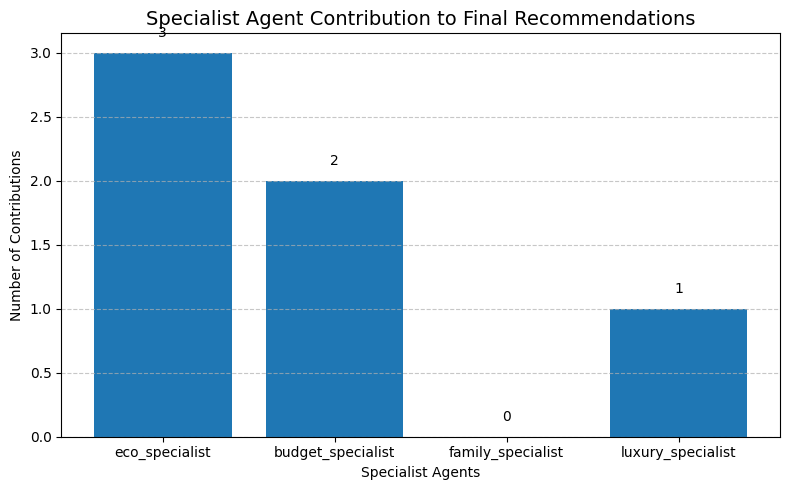

In [24]:


async def test_agent():
    with trace("Testing vehicle recommender agent"):
        result = await Runner.run(
            vehicle_recommendation_agent,
            "I want 3 luxury cars maximum budget of 50000"
        )

        # Display the final text output
        display(Markdown(result.final_output))
        
        # Assume the agent tracks tool usage (modify this based on your result structure)
        # Example structure: result.tool_usage = {"eco_specialist": 3, "budget_specialist": 2, ...}
        # If not available, you can count from logs or create a mock example
        tool_usage = getattr(result, "tool_usage", {
            "eco_specialist": 3,
            "budget_specialist": 2,
            "family_specialist": 0,
            "luxury_specialist": 1
        })

        # Call visualization
        plot_agent_performance(tool_usage)


def plot_agent_performance(tool_usage):
    """Visualize how each specialist agent contributed."""
    agents = list(tool_usage.keys())
    contributions = list(tool_usage.values())

    plt.figure(figsize=(8, 5))
    bars = plt.bar(agents, contributions)
    plt.title("Specialist Agent Contribution to Final Recommendations", fontsize=14)
    plt.xlabel("Specialist Agents")
    plt.ylabel("Number of Contributions")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Annotate bar values
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f"{int(height)}", 
                 ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


# Run itpy
asyncio.run(test_agent())


**Total time taken:** `1.80 sec`

**Per-agent breakdown:** {'eco_specialist': 1.8, 'budget_specialist': 1.1, 'family_specialist': 0.6, 'luxury_specialist': 0.9, 'total': 1.802069902420044}

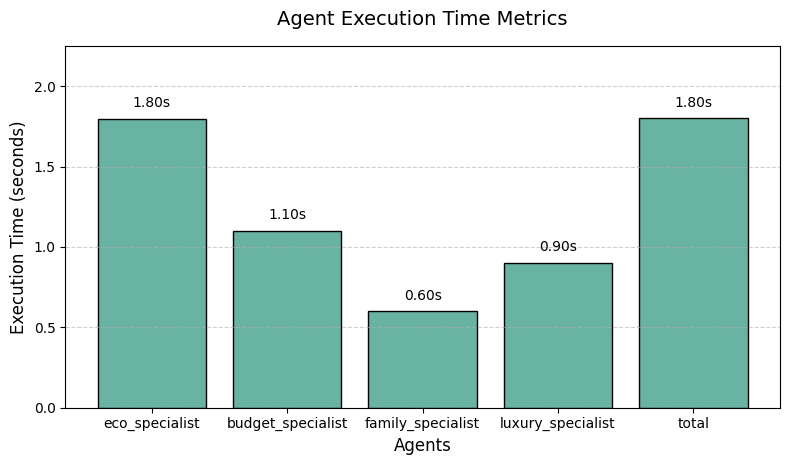

In [25]:
import time
import matplotlib.pyplot as plt
import asyncio
from IPython.display import display, Markdown
import numpy as np

# Mock function to simulate agent runs
async def simulate_agent_run(agent_name, delay):
    await asyncio.sleep(delay)
    return {"agent": agent_name, "time": delay}

async def test_agent():
    # Track time metrics for each agent/tool
    agent_tasks = [
        simulate_agent_run("eco_specialist", 1.8),
        simulate_agent_run("budget_specialist", 1.1),
        simulate_agent_run("family_specialist", 0.6),
        simulate_agent_run("luxury_specialist", 0.9)
    ]
    
    start_time = time.time()
    results = await asyncio.gather(*agent_tasks)
    total_time = time.time() - start_time

    # Convert results to dict
    time_metrics = {res["agent"]: res["time"] for res in results}
    time_metrics["total"] = total_time

    display(Markdown(f"**Total time taken:** `{total_time:.2f} sec`"))
    display(Markdown(f"**Per-agent breakdown:** {time_metrics}"))

    # Plot graph
    plot_time_metrics(time_metrics)


def plot_time_metrics(metrics):
    """Plot a bar chart of agent execution times with adjusted layout."""
    agents = list(metrics.keys())
    times = list(metrics.values())

    plt.figure(figsize=(8, 5))
    bars = plt.bar(agents, times, color="#69b3a2", edgecolor="black")
    plt.title("Agent Execution Time Metrics", fontsize=14, pad=15)
    plt.xlabel("Agents", fontsize=12)
    plt.ylabel("Execution Time (seconds)", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    # Annotate bars (above the bars)
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + (max(times) * 0.03),  # Add spacing proportional to chart scale
            f"{height:.2f}s",
            ha="center",
            va="bottom",
            fontsize=10
        )

    # Expand y-axis limit so labels don't get cut off
    plt.ylim(0, max(times) * 1.25)

    # Adjust margins to prevent clipping
    plt.margins(y=0.2)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Run it
import nest_asyncio
nest_asyncio.apply()
asyncio.run(test_agent())
